# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos.
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas.
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [2]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son numéricas?**



# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


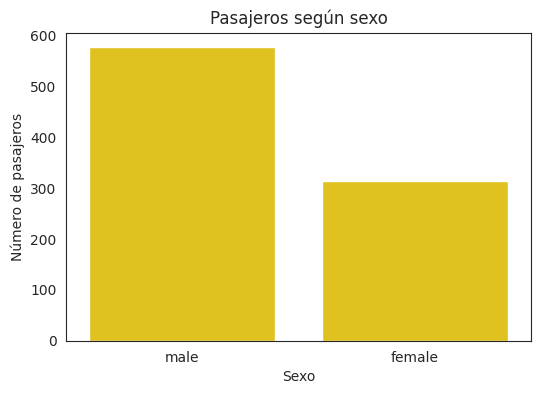

In [3]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?

La clase 3 contiene la mayoría de pasajeros

- La muestra está balanceada entre las tres clases?

La clase 3 domina por sobre la clase 1 y 2, resultando una muestra no balanceada

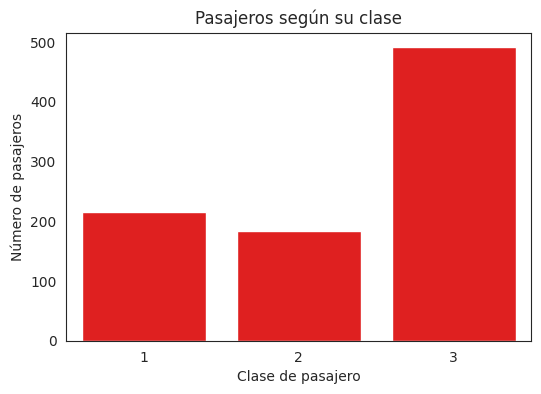

In [4]:
# Escriba aquí su código

plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="red")

plt.xlabel("Clase de pasajero")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según su clase")

plt.show()


**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?

Visualizando el histograma, la gran mayoría se concentra entre los 20-40 años

- ¿La distribución parece simétrica?

No es perfectamente simétrica, ya que, presenta una cola que se extiende mucho hacia las edades mayores, en cambio, por el lado izquierdo, se corta abruptamente.


- ¿El número de bins cambia su interpretación?

La conclusión final se mantiene cambiando el número de bins, pero puede cambiar la percepción de detalles. Con pocos bins tenemos picos más abruptos, a diferencia de una cantidad mayor de bins que genera una distribución más suave.


Text(0.5, 1.0, 'Distribución de edades')

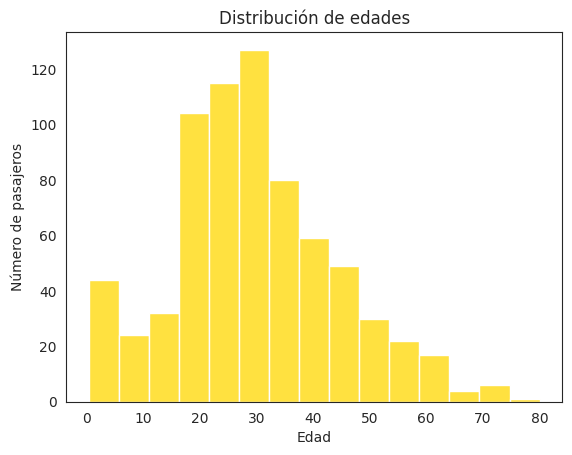

In [5]:
# Escriba aquí su código

sns.histplot(data=titanic, x="Age", bins=15, color='gold')

plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.title("Distribución de edades")


**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?

No, la distribución es asimétrica. La gran mayoría de los datos están comprimidos hacia la izquierda.

- ¿Existen tarifas muy superiores al resto?

Sí. Observando el boxplot, vemos que hay múltiples outliers que se extienden hacia la derecha de los datos, los cuales son personas que pagan una cantidad mayor a diferencia de la gran mayoría.

- ¿Qué podría significar esto?

Significa que la gran mayoría de pasajeros pagó tarifas bajas, mientras que un grupo muy reducido de personas pagó sumas altísimas para acomodaciones superiores al resto.


Text(0.5, 1.0, 'Distribución de tarifas')

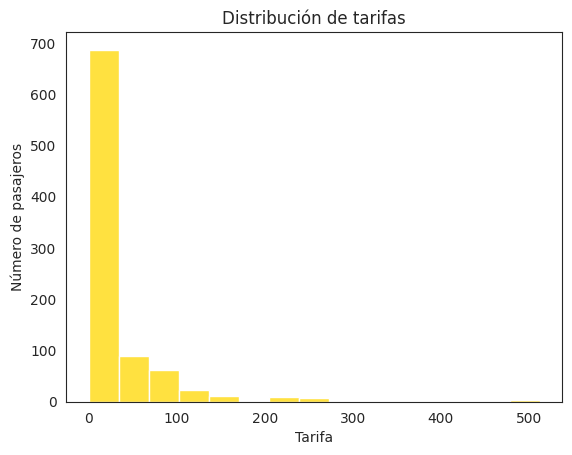

In [6]:
# Escriba aquí su código

sns.histplot(data=titanic, x="Fare", bins=15, color='gold')

plt.xlabel("Tarifa")
plt.ylabel("Número de pasajeros")
plt.title("Distribución de tarifas")


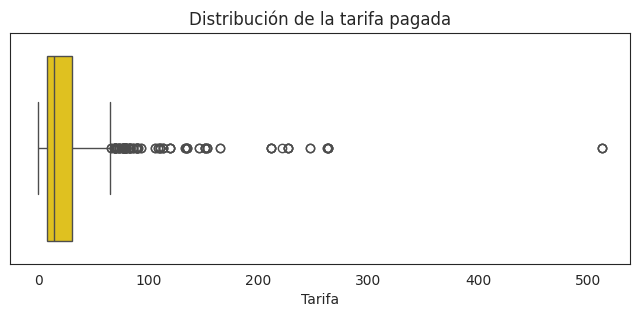

In [7]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=titanic, x="Fare", color="gold")
plt.xlabel("Tarifa")
plt.title("Distribución de la tarifa pagada")
plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [8]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


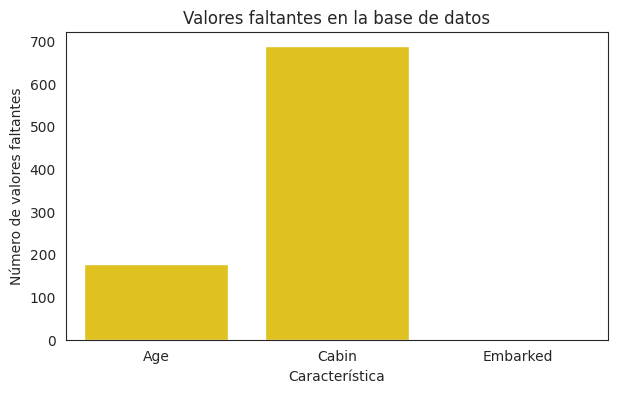

In [9]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?

Sí, son valores bastante similares

- Es la media una buena representación de una edad típica?

En este caso si. La media y la mediana tienen valores muy similares, lo cual nos indica que la distribución es bastante simétrica. Si hubiese habido un grupo grande personas con valores de edad atípicos (personas de 3ra edad o niños pequeños) la media se habría disparado y ya no representativa.


In [10]:
media = np.mean(titanic['Age'])

mediana = np.nanmedian(titanic['Age'])

print(f"Media: {media}")
print(f"Mediana: {mediana}")

Media: 29.69911764705882
Mediana: 28.0


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?

No sería lo más óptimo, ya que faltan alrededor de 177 datos de edades, los cuales son una cantidad suficiente que podría cambiar la distribución de edad obtenidas, por lo que asumir que esos datos faltantes son iguales a la media sería un error.

- Qué problema podría producir esa decisión en la distribución de edades?

Crearía un peak artificial enorme en el centro de la distribución, alterando la posible real distribución de edades.

- Qué otra estrategia consideraría?

Podría calcular la mediana de la edad según agrupaciones, ejemplo: calcular la mediana de edad según la clase de pasajero, la cual podría llegar a tener alguna tendencia en la edad.


**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?

La cabina es una caracteristica de agrupación, por lo que habría que intentar adivinar el número exacto de cabina para una cantidad exagerada de datos, por lo que no intentaría rellenar la variable.

- Eliminaría la característica?

Sí, ya que con la cantidad de información obtenida de las otras caracteristicas podría ser suficiente.

- Podría el hecho de conocer o no la cabina contener información por sí mismo?

Sí. Al observar algunos datos, es muy probable que los pasajeros de primera clase tuvieran sus cabinas bien registradas, mientras que los de tercera no. Podría crearse una columna con una variable binaria que me indique si el pasajero tiene la cabina asignada (1) o si el dato falta (0).


**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?

Al faltar solo 2 datos, es seguro reemplazar esos valores por la moda (el puerto de embarque más frecuente), ya que, al ser pocos datos, no tiene la capacidad de alterar fuertemente la moda.

- Por qué el tratamiento puede ser distinto al de `Cabin`?

Porque rellenar 2 valores no afectará a la estadística general ni causará sesgos, a diferencia de Cabin, donde falta la inmesa mayoría de datos.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


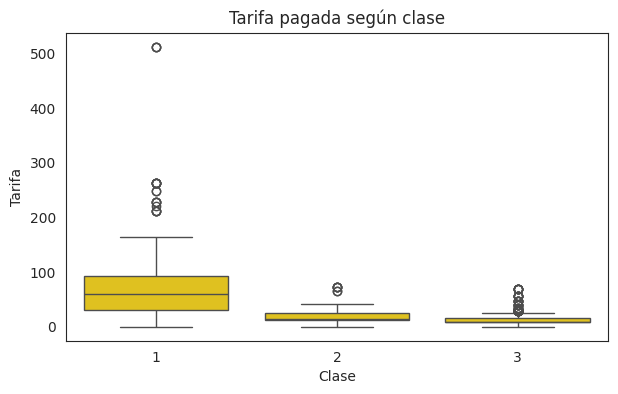

In [11]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?

Sí. A medida que subimos de clase (de 3ra a 1ra), la mediana de la tarifa y el promedio aumentan significativamente

- Hay dispersión dentro de cada clase?

Bastante. La primera clase tiene una dispersión significativa, lo que indica una gran diferencia entre los pasajes más baratos y los más caros dentro de esa misma clase. Para el caso de las clases 2 y 3 tienen menor dispersión.

- Existen valores extremos?

Sí. En las tres clases existen valores extremos o outliers.

- Diría que `Fare` y `Pclass` contienen exactamente la misma información?

Estan correlacionadas, pero no contienen exactamente la misma información. Fare entrega información con mayor detalle, por ejemplo, existen pasajeros de tercera clases que pagaron tarifas más altas que pasajeros de primera clase, algo que no sabríamos si solamente observamos Pclass.


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?

No, existe una clara diferencia en la distribución de edad dependiendo de la clase de pasajero.

- Qué diferencias observa?

A medida que vamos a clases mejores (clase 1), aumenta la edad típica del pasajero. Los pasajeros de 1ra clase contiene la mediana alrededor de los 37 años, los de 2da clase en los 30 años y los de 3ra clase cerca de los 24 años, siendo los más jovenes.

Text(0.5, 1.0, 'Edad según clase')

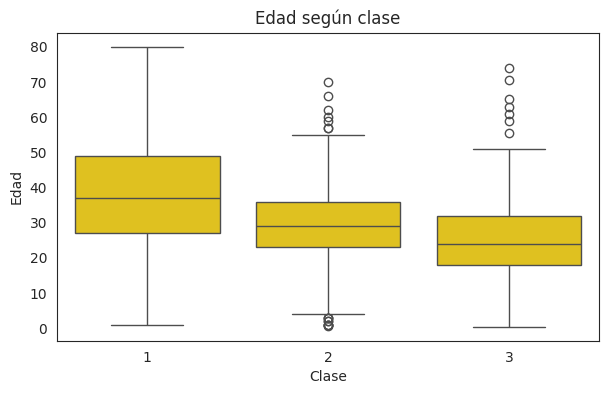

In [12]:
# Escriba aquí su código
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Age", color='gold')

plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Edad según clase")


**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [13]:
# Complete el código
titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1

titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Familia
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?

La gran mayoría viajaba solo.

- Hay grupos familiares muy grandes?
Si, se pueden observar valores atípicos de hasta familia de 7, 8 u 11 personas

- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?

Sí. Si miras solo SibSp y ves un 1 ahí viajan 2 pero luego esa misma persona podría tener un 2 en Parch, por lo que al final sería un grupo de 4 personas viajando. Por lo tanto, unir estas variables nos da el valor real del núcleo familiar directo.


Text(0.5, 1.0, 'Pasajeros según tamaño del grupo familiar')

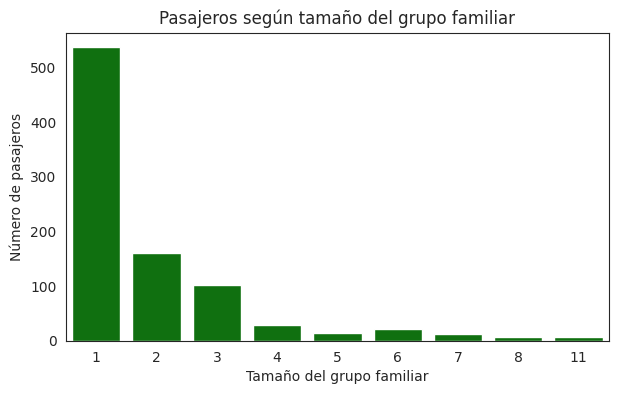

In [14]:
# Escriba aquí su código
plt.figure(figsize=(7, 4))
sns.countplot(data=titanic, x="Familia", color="green")
plt.xlabel("Tamaño del grupo familiar")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según tamaño del grupo familiar")



# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


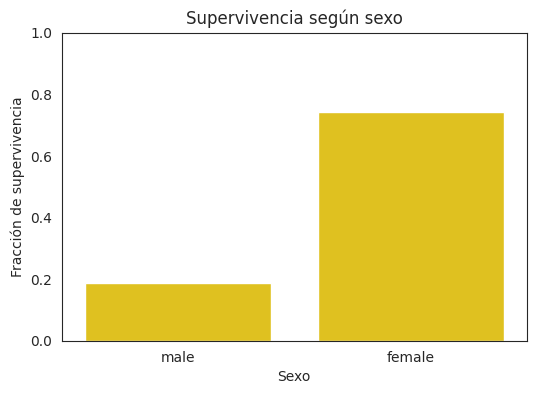

In [15]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?

No, es muy distinta entre si. Las mujeres tuvieron una fracción de supervivencia superior al 70%, mientras que los hombres a lo más tuvieron un 20%.

- Podemos concluir a partir de este gráfico por qué existe la diferencia?

No podriamos a partir de este gráfico concluir la diferencia. El gráfico nos muestra solo la observación, pero no nos da un contexto de por qué. Para concluir las causas de la diferencia necesitaríamos información historica o variables cruzadas de alguna forma.


### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?

Hay diferencias muy marcadas entre las fracciones de supervivencia de cada clase.

- Existe una tendencia?

Hay una tendencia clara: a mejor clase, mayor es la probabilidad de sobrevivir. Los pasajeros de 1ra clase sobrevivieron en mayor proporción, seguidos por lo de 2da y finalmenente los de 3ra clase que tuvieron la menor fracción de supervivencia.


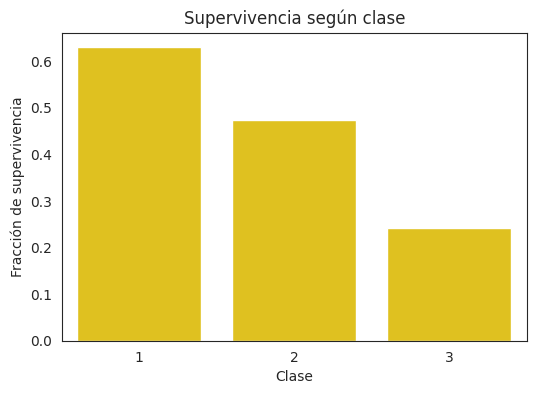

In [16]:
# Escriba aquí su código

plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='gold')
plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.show()


**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?

Analizando la distribución, la edad promedio de los que sobrevivieron y los que no es muy similar, pero pareciera que sí existe una asociación en los extremos de edad.

- Hay algún grupo de edad que llame particularmente su atención?

El grupo de niños (menores de 14 años aproximadamente), es un grupo de edad donde la barra de sobrevivientes está casi a la misma altura que los que no sobrevivieron.


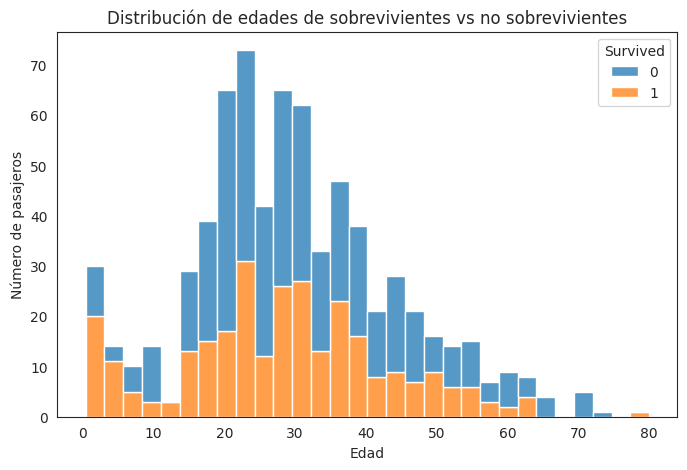

In [17]:
# Escriba aquí su código

plt.figure(figsize=(8,5))
sns.histplot(data=titanic, x="Age", hue="Survived", bins=30, multiple="stack")
plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.title("Distribución de edades de sobrevivientes vs no sobrevivientes")
plt.show()


**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?

Desfavorable. Los pasajeros que viajaban solos tienen una fracción de supervivencia relativamente menor (30% aprox) en comparación a los que viajaban con 1 a 3 personas más.

- La relación parece simple?

La relación no es lineal. La supervivencia aumenta inicialmente a medida que el grupo familiar crece de 1 a 4 personas, pero luego hay una caida brusca.

- Qué ocurre con los grupos familiares grandes?

Los grupos familiares grandes de 5 personas o más, tuvieron tasas de supervivencia bajas.


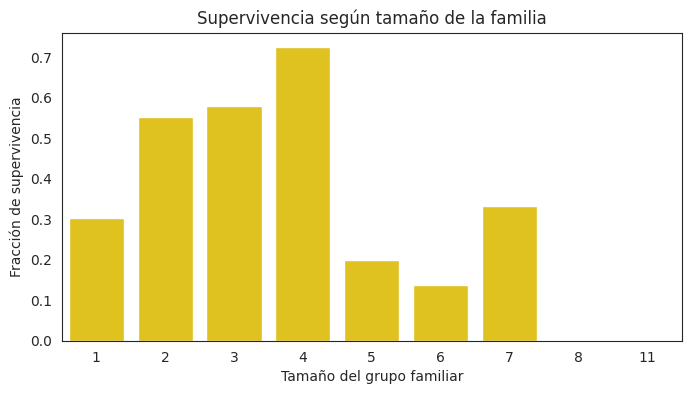

In [18]:
# Escriba aquí su código

plt.figure(figsize=(8,4))
sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color='gold')
plt.xlabel("Tamaño del grupo familiar")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según tamaño de la familia")
plt.show()

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


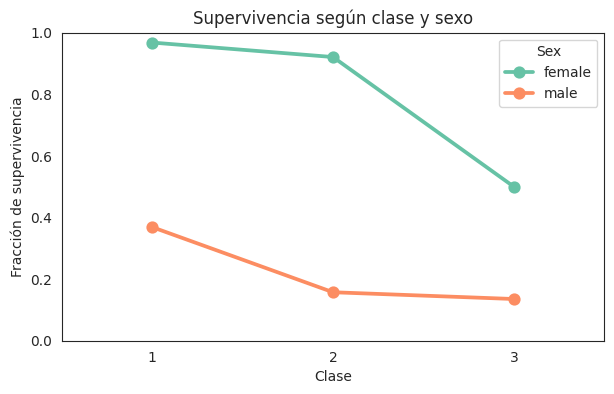

In [19]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?

Tienen una tendencia similar, ambas caen al pasar de 1ra a 3ra clase. Sin embargo, la supervivencia de las mujeres se mantiene altísima en 1ra y 2da clase y recién se desploma en la 3ra, en comparación con los hombres, donde ya es baja desde la 1ra clase y decae aún más en la 2da y 3ra clase.

- Qué información se perdía cuando mirábamos solamente `Pclass`?

Se perdía el impacto enorme que tiene el género. Al ver solo la clase, pensábamos que todos en 1ra clase tenían altísimas chances de vivir, pero al juntar los datos vemos que un hombre de 1ra clase tiene menor probabilidad de supervivencia que una mujer de 3ra clase.

- Qué información se perdía cuando mirábamos solamente `Sex`?

Se asume erróneamente que todas las mujeres o hombres se salvan por igual en su respectivo género. Al cruzar los datos con la clase, nos dimos cuenta que ser mujer en 3ra clase tenía casi la mitad de fracción de supervivencia con respecto a las mujeres de 1ra y 2da clase.

- Hay algún grupo particularmente favorecido o desfavorecido?

El grupo más favorecido son las mujeres de 1ra y 2da clase. El grupo más desfavorecido son los hombres de 2da y 3ra clase.



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [20]:
# Complete el código

titanic["Persona"] = titanic["Sex"].map({"male": "hombre", "female": "mujer"})
titanic.loc[titanic["Age"] < 16, "Persona"] = "niño/a"


titanic["Persona"].value_counts()


,count
Persona,
hombre,537
mujer,271
niño/a,83


**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?

No. Los niños presentan un patrón de supervivencia mucho más alto que los hombres adultos, sobre todo en la 1ra y 2da clase. Sería más parecido al de las mujeres.

- La clase sigue siendo importante dentro de cada grupo?

Sí. En general la probabilidad de supervivencia decae mucho a medida que bajamos de clase para todos.


- Qué combinación de características parece asociarse con la mayor supervivencia?

Ser mujer o niño/a y viajar en 1ra o 2da clase.


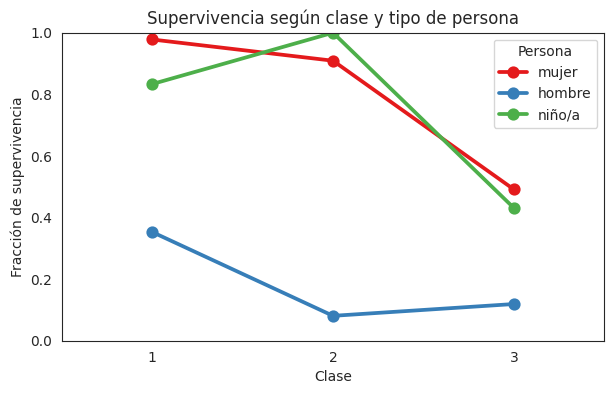

In [21]:
# Escriba aquí su código
plt.figure(figsize=(7,4))
sns.pointplot(data=titanic, x="Pclass", y="Survived", hue="Persona", palette="Set1", errorbar=None)


plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y tipo de persona")
plt.ylim(0,1)
plt.show()

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


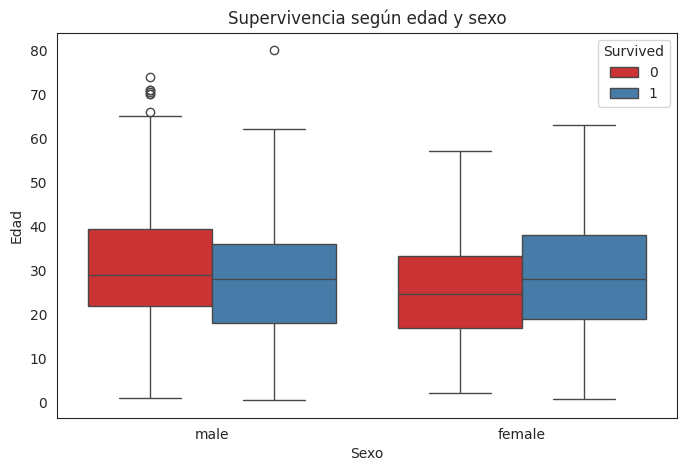

In [22]:
# Pregunta:

# ¿La distribución de edad de los sobrevivientes es diferente entre hombres y mujeres?

# Código:
plt.figure(figsize=(8, 5))
sns.boxplot(data=titanic, x="Sex", y="Age", hue="Survived", palette="Set1")



plt.xlabel("Sexo")
plt.ylabel("Edad")
plt.title("Supervivencia según edad y sexo")
plt.show()


# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**

No. Los datos solo nos muestran los números finales de quiénes sobrevivieron, pero no nos explican los motivos reales ni los protocolos de evacuación que ocurrieron durante el desastre.

- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**

Necesitaríamos testimonios de los sobrevivientes, registros sobre las órdenes dadas por los altos mandos del barco o los protocolos oficiales de la tripulación.

- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

Podría ser que las habitaciones o camas de mujeres y niños estuvieran de forma estratégica más cerca de la superficie del barco o de los botes salvavidas.

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.

La muestra de datos estaba compuesta en su mayoría por hombres. La clase dominante era la tercera clase. Respecto a las edades, la gran mayoría eran adultos jovenes de entre los 20-40 años con una mediana de 28 años. Finalmente, la gran mayoría de los pasajeros viajaban solos, sin familiares.

### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo: Las mujeres tuvieron una tasa de supervivencia ampliamente mayor que los hombres.

- clase: Viajar en 1ra clase aseguraba una mayor probabilidad de sobrevivir, disminuyendo al bajar a 2da clase y cayendo fuertemente en 3ra clase.

- edad: Ser niño (menores de 16 años) estaba ligado a una mayor probabilidad de supervivencia con respecto a los adultos.

- viajar solo o acompañado: Viajar con un grupo familiar pequeño (1 a 3 personas más) resultó ser más favorable que viajar solo. Sin embargo, los grupos familiares grandes (5 o más personas adicionales) casi no sobrevivieron.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Al analizar solo la clase, parecía que estar en 1ra clase garantizaba la supervivencia. Luego, al cruzar la Clase y el Sexo, encontramos que mujeres y niños de clases menores que 1ra clase tenían mayores probabilidades de supervivencia (50% aprox en 3ra clase) que un hombre de 1ra clase (menos del 40%).


### 4. Encontró características que contienen información relacionada?

Sí, las variables Pclass y Fare contienen información correlacionada, ya que las mejores clases pagaban las tarifas más altas. Sin embargo, no son idénticas, ya que Fare muestra también que dentro de una misma clase existe una enorme variación de precios pagadas.


### 5. Qué resultado le pareció más inesperado?

Observación: La tasa de supervivencia de los pasajeros que viajaban en grupos familiares grandes (5 o más personas) fue muy baja, casi nula en comparación con los que viajaban solos o en grupos pequeños.

Hipótesis: Probablemente los grupos familiares grandes tuvieron muchas dificultades logísticas para mantenerse juntos durante el caos mientras evacuaban, o quizás se negaron a subir a los botes salvavidas a menos que hubiera espacio para toda la familia completa, lo cual resultó trágico.


# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

Era una mujer adulta o un niño/a, que viajaba con pasaje de primera o segunda clase, y que estaba acompañado por un grupo familiar pequeño (1 a 3 familiares). Este perfil reúne a las características biológicas y sociales que presentaron las mayores tasas de supervivencia de la muestra, evidenciando que tanto el género y la edad, como la posible ventaja logística de las clases más altas fueron factores determinantes para sobrevivir al desastre.
